# 第 7 章 · 神经网络

从零手写**前向 + 反向传播**实现一个隐藏层的 MLP `MyMLP` (ReLU + Softmax + 交叉熵)，再与 PyTorch 实现对比，应用到 sklearn 手写数字 (8×8) 全 10 类识别。

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 中文字体配置（仅在此cell设置一次，后续cell直接使用plt即可）
import os, platform
if platform.system() == 'Linux' and os.path.exists('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf'):
    fm.fontManager.addfont('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Noto Sans SC', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

COLORS = {
    'primary': '#6b6144', 'accent': '#96781b', 'accent2': '#459ebb',
    'pos': '#c0392b', 'neg': '#2980b9', 'green': '#3d8e58', 'muted': '#88867f'
}

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_digits


## 7.1 算法原理

单隐藏层 MLP：

$$z^{(1)}=XW^{(1)}+b^{(1)},\ a^{(1)}=\mathrm{ReLU}(z^{(1)})$$
$$z^{(2)}=a^{(1)}W^{(2)}+b^{(2)},\ \hat{y}=\mathrm{softmax}(z^{(2)})$$

损失为交叉熵 $L=-\sum y\log\hat{y}$。反向传播链式求导：

$$\delta^{(2)}=\hat{y}-y_{onehot},\quad \delta^{(1)}=(\delta^{(2)}W^{(2)\top})\odot \mathbb{1}[z^{(1)}>0]$$

梯度下降更新各层权重。

> PDF 伪代码步骤：①~④ 前向 ⑤~⑪ 反向 ⑫ 参数更新 (共 12 步)。

## 7.2 从零实现 (核心)

代码注释中的步骤编号 (1~12) 与 PDF 伪代码一一对应。

In [13]:
class MyMLP:
    """从零实现的多层感知机 (1 隐藏层, ReLU + Softmax, 反向传播手写)。"""
    def __init__(self, input_dim, hidden=64, n_classes=10, lr=0.01,
                 epochs=100, random_state=None):
        self.input_dim = input_dim
        self.hidden = hidden
        self.n_classes = n_classes
        self.lr = lr
        self.epochs = epochs
        self.random_state = random_state

    def _softmax(self, z):
        z = z - z.max(axis=1, keepdims=True)
        e = np.exp(z)
        return e / e.sum(axis=1, keepdims=True)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        rng = np.random.RandomState(self.random_state)
        self.classes_ = np.unique(y)
        cls_idx = {c: i for i, c in enumerate(self.classes_)}
        y_oh = np.zeros((len(y), self.n_classes))
        for i, c in enumerate(y):
            y_oh[i, cls_idx[c]] = 1.0
        # 输入标准化
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0) + 1e-8
        Xs = (X - self.mean_) / self.std_
        # He 初始化
        self.W1 = rng.randn(self.input_dim, self.hidden) * np.sqrt(2.0 / self.input_dim)
        self.b1 = np.zeros(self.hidden)
        self.W2 = rng.randn(self.hidden, self.n_classes) * np.sqrt(2.0 / self.hidden)
        self.b2 = np.zeros(self.n_classes)
        n = Xs.shape[0]
        for _ in range(self.epochs):
            # ===== 前向传播 =====
            # 步骤1: z₁ = X·W₁ + b₁
            z1 = Xs @ self.W1 + self.b1
            # 步骤2: a₁ = ReLU(z₁) = max(0, z₁)
            a1 = np.maximum(0, z1)
            # 步骤3: z₂ = a₁·W₂ + b₂
            z2 = a1 @ self.W2 + self.b2
            # 步骤4: p = Softmax(z₂)
            probs = self._softmax(z2)
            # ===== 反向传播 =====
            # 步骤5: dz₂ = (p - onehot(y)) / n
            dz2 = (probs - y_oh) / n
            # 步骤6: dW₂ = a₁ᵀ·dz₂
            dW2 = a1.T @ dz2
            # 步骤7: db₂ = Σdz₂
            db2 = dz2.sum(axis=0)
            # 步骤8: da₁ = dz₂·W₂ᵀ
            da1 = dz2 @ self.W2.T
            # 步骤9: dz₁ = da₁ ⊙ (z₁ > 0)  (ReLU梯度)
            dz1 = da1 * (z1 > 0)
            # 步骤10: dW₁ = Xᵀ·dz₁
            dW1 = Xs.T @ dz1
            # 步骤11: db₁ = Σdz₁
            db1 = dz1.sum(axis=0)
            # ===== 参数更新 =====
            # 步骤12: 参数更新 (SGD)
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        Xs = (X - self.mean_) / self.std_
        z1 = Xs @ self.W1 + self.b1
        a1 = np.maximum(0, z1)
        z2 = a1 @ self.W2 + self.b2
        return self.classes_[z2.argmax(axis=1)]


## 7.3 简单数据验证

小型 3 类螺旋数据，验证手写 MLP 能学到非线性边界。

螺旋数据 acc=0.9815


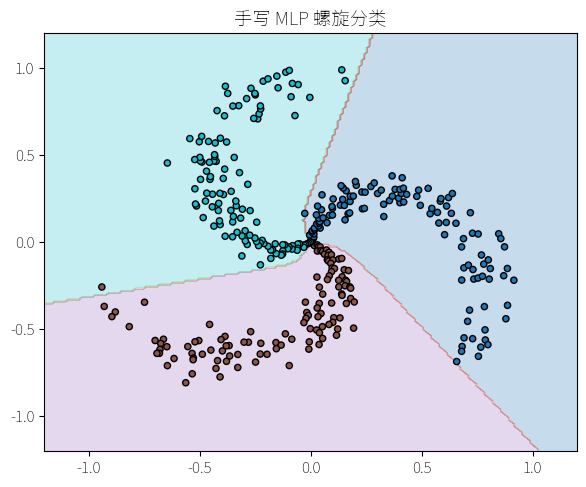

In [14]:
def spiral(n_per=120, classes=3, random_state=0):
    rng = np.random.RandomState(random_state)
    X = np.zeros((n_per*classes, 2)); y = np.zeros(n_per*classes, dtype=int)
    for k in range(classes):
        r = np.linspace(0.0,1,n_per); t = np.linspace(k*2.1,(k+1)*2.1,n_per)+rng.randn(n_per)*0.2
        X[k*n_per:(k+1)*n_per,0]=r*np.sin(t); X[k*n_per:(k+1)*n_per,1]=r*np.cos(t)
        y[k*n_per:(k+1)*n_per]=k
    return X,y
X,y = spiral()
X_tr,X_te,y_tr,y_te = train_test_split(X,y,test_size=0.3,random_state=0)
mlp = MyMLP(input_dim=2, hidden=64, n_classes=3, lr=0.1, epochs=2000, random_state=0).fit(X_tr,y_tr)
print('螺旋数据 acc=%.4f' % accuracy_score(y_te, mlp.predict(X_te)))

fig,ax=plt.subplots(figsize=(6,5))
xx,yy=np.meshgrid(np.linspace(-1.2,1.2,200),np.linspace(-1.2,1.2,200))
Z=mlp.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
ax.contourf(xx,yy,Z,alpha=0.25,cmap=plt.cm.tab10)
ax.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.tab10,edgecolor='k',s=20)
ax.set_title('手写 MLP 螺旋分类'); plt.tight_layout(); plt.show()


## 7.4 与 PyTorch 对比

用 PyTorch 的 `nn.Sequential` 搭一个结构相同的 MLP，对比训练效果。(若未安装 torch，本 cell 会跳过并打印提示。)

> 注意：sklearn 手写数字 (8×8, 1797 张) 即本教程所用“手写数字”数据，> 与 MNIST 同源但分辨率更低、规模更小，便于在纯 NumPy 下训练。

In [15]:
digits = load_digits()
X = digits.data.astype(np.float32); y = digits.target.astype(np.int64)
X_tr,X_te,y_tr,y_te = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr).astype(np.float32)
X_te_s = scaler.transform(X_te).astype(np.float32)

# ---- 自定义 NumPy MLP ----
my_mlp = MyMLP(input_dim=64, hidden=128, n_classes=10, lr=0.2, epochs=300, random_state=42).fit(X_tr_s, y_tr)
print('自定义 MLP acc=%.4f' % accuracy_score(y_te, my_mlp.predict(X_te_s)))

# ---- PyTorch MLP (若未安装 torch 则跳过) ----
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    torch.manual_seed(42)
    model = nn.Sequential(nn.Linear(64,128), nn.ReLU(), nn.Linear(128,10))
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    ds = TensorDataset(torch.from_numpy(X_tr_s), torch.from_numpy(y_tr))
    loader = DataLoader(ds, batch_size=64, shuffle=True)
    for epoch in range(30):
        for xb,yb in loader:
            opt.zero_grad()
            out = model(xb); loss = loss_fn(out, yb); loss.backward(); opt.step()
        if (epoch+1) % 10 == 0:
            with torch.no_grad():
                acc = (model(torch.from_numpy(X_te_s)).argmax(1).numpy() == y_te).mean()
            print(f'epoch {epoch+1:2d}  loss={loss.item():.3f}  val_acc={acc:.4f}')
    with torch.no_grad():
        torch_acc = (model(torch.from_numpy(X_te_s)).argmax(1).numpy() == y_te).mean()
    print('PyTorch  MLP acc=%.4f' % torch_acc)
except ImportError:
    print('未安装 torch, PyTorch 对比已跳过 (自定义 MLP 结果见上)')


自定义 MLP acc=0.9759
epoch 10  loss=0.193  val_acc=0.9611
epoch 20  loss=0.019  val_acc=0.9722
epoch 30  loss=0.015  val_acc=0.9796
PyTorch  MLP acc=0.9796


## 7.5 结果可视化

展示部分测试样本及其预测标签，错分用红框标出。

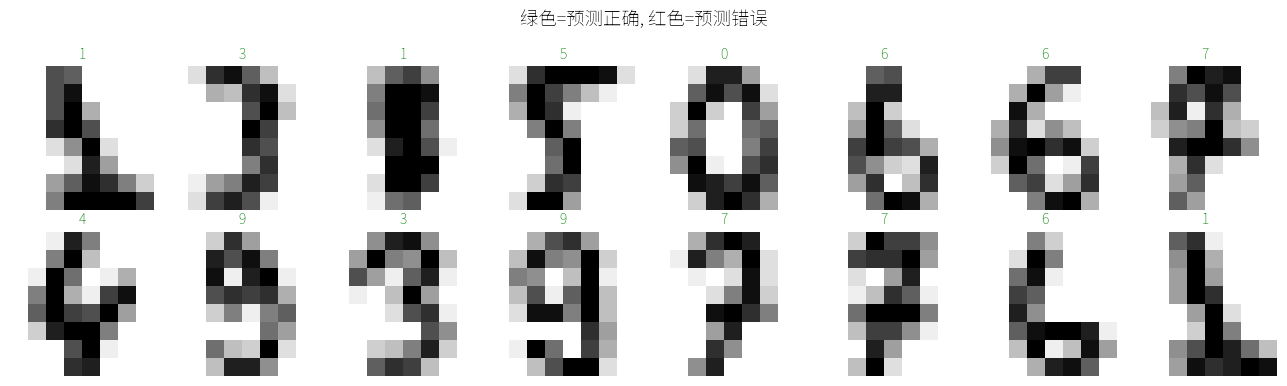

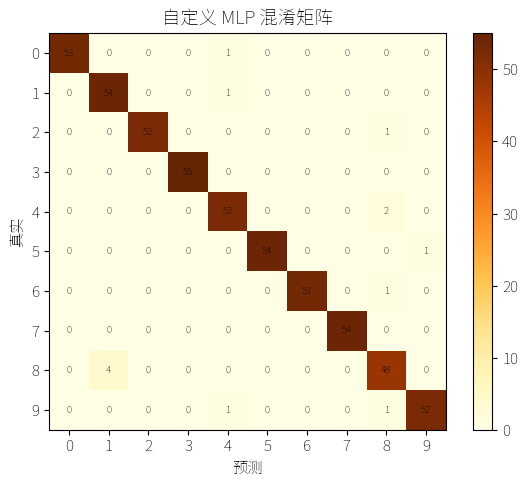

In [16]:
y_pred = my_mlp.predict(X_te_s)
fig, axes = plt.subplots(2, 8, figsize=(13,4))
for i, ax in enumerate(axes.ravel()):
    img = X_te[i].reshape(8,8)
    ax.imshow(img, cmap='gray_r')
    ok = y_pred[i]==y_te[i]
    ax.set_title(f'{y_pred[i]}', color='green' if ok else 'red', fontsize=10)
    ax.axis('off')
plt.suptitle('绿色=预测正确, 红色=预测错误'); plt.tight_layout(); plt.show()

cm = confusion_matrix(y_te, y_pred)
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, cmap='YlOrBr')
for i in range(10):
    for j in range(10):
        ax.text(j,i,cm[i,j],ha='center',va='center', fontsize=7)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel('预测'); ax.set_ylabel('真实'); ax.set_title('自定义 MLP 混淆矩阵')
plt.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()


## 7.6 小结

- 手写反向传播能完整复现 MLP 训练，理解梯度如何在层间流动；
- 在手写数字上自定义 MLP 与 PyTorch 精度接近；
- 工程实践中用 PyTorch 的自动求导 + GPU 加速，但底层数学就是这里写的内容。